In [1]:
### import libraries

import pandas as pd
import numpy as np
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

In [2]:
# 1. Load the dataset with cp1252 encoding to handle special characters common in tweets
df = pd.read_csv('test.csv', encoding="cp1252")
df.head()

# Check dataset dimensions to understand the scale of the analysis 
df.shape

(4815, 9)

In [3]:
# 2. Define a regex-based cleaning function to remove noise from raw tweets 
def clean(text):
    text = str(text).lower()                 # Standardize to lowercase
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text)          # Remove Twitter handles (@mentions)
    text = re.sub(r'[^a-z\s]', ' ', text)     # Remove special characters and numbers
    text = ' '.join(text.split())             # Remove extra whitespace
    return text

# Apply the cleaning function to create a new processed text column 
df['clean_text'] = df['text'].apply(clean)
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),clean_text
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0,last session of the day
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0,shanghai is also really exciting precisely sky...
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0,recession hit veronique branquinho she has to ...
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0,happy bday
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0,i like it


In [4]:
# 3. Handle data integrity by identifying and removing empty processed strings 
df['clean_text'] = df['clean_text'].replace('', np.nan)
df = df.dropna(subset=['clean_text', 'sentiment'])
df = df.reset_index(drop=True) # Reset index to maintain a clean sequence after dropping rows


In [5]:
# 4. Initialize TF-IDF Vectorizer to convert text into numerical features [cite: 1]
# Uses unigrams and bigrams (ngram_range=(1,2)) to capture context 
tfidf = TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=4, stop_words='english')

# Transform text into a sparse matrix and define the target label 
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

# Check for class imbalance in the target labels
df['sentiment'].value_counts()

sentiment
neutral     1429
positive    1103
negative    1001
Name: count, dtype: int64

In [6]:
# 5. Split data into training (80%) and testing (20%) sets
# 'stratify=y' ensures the sentiment distribution remains consistent in both sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# 6. Initialize Logistic Regression with 'balanced' weights to handle uneven class sizes 
model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', class_weight='balanced')

# Train the model on the TF-IDF features 
model.fit(X_train, y_train)

C:\Users\gidad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [8]:
# 7. Generate predictions on the unseen test set
y_pred = model.predict(X_test)

In [9]:
# 8. Print performance metrics to evaluate model precision and recall
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.2%}')
print(classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

Accuracy Score: 64.21%
              precision    recall  f1-score   support

    negative       0.62      0.66      0.64       200
     neutral       0.61      0.60      0.60       286
    positive       0.71      0.68      0.69       221

    accuracy                           0.64       707
   macro avg       0.65      0.65      0.65       707
weighted avg       0.64      0.64      0.64       707



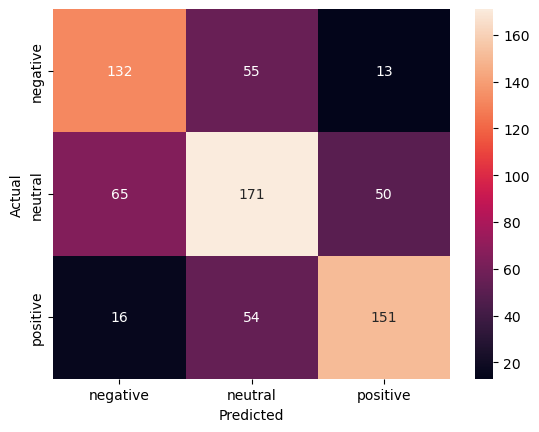

In [10]:
# 9. Visualize the confusion matrix to see where the model is misclassifying tweets 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [11]:
# 10. Utility function to test the model with new, raw text strings 
def predict_my_tweet(new_tweet):
    cleaned = clean(new_tweet)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    probs = model.predict_proba(vector)[0] # Extract confidence scores for each class

    print(f'Tweet: {new_tweet}')
    print(f'Sentiment: {prediction.upper()}')
    print(f'Confidence: {max(probs)}')

# Test cases for manual verification [cite: 2]
predict_my_tweet("I am so frustrated with this service, it is terrible.")
predict_my_tweet("Today is a standard Monday morning.")

Tweet: I am so frustrated with this service, it is terrible.
Sentiment: NEGATIVE
Confidence: 0.4760610659690365
Tweet: Today is a standard Monday morning.
Sentiment: NEUTRAL
Confidence: 0.4614022946605602


In [12]:
# 11. Interpretability: Extract word importance from the model coefficients 
feature_names = np.array(tfidf.get_feature_names_out())

for i, class_label in enumerate(model.classes_):
    # Sort weights for each specific class to find the most influential words 
    top_indices = np.argsort(model.coef_[i])[-10:]
    bottom_indices = np.argsort(model.coef_[i])[:10]
    
    print(f"\n--- TOP 10 WORDS FOR {class_label.upper()} ---")
    print(feature_names[top_indices])


--- TOP 10 WORDS FOR NEGATIVE ---
['sick' 'tired' 'poor' 'sucks' 'stupid' 'bad' 'sorry' 'hate' 'sad' 'miss']

--- TOP 10 WORDS FOR NEUTRAL ---
['google' 'black' 'second' 'office' 'live' 'guess' 'eating' 'said' 'vegas'
 'lunch']

--- TOP 10 WORDS FOR POSITIVE ---
['happy' 'cool' 'awesome' 'amazing' 'great' 'good' 'nice' 'thank' 'thanks'
 'love']


In [13]:
# 12. Save the trained model and vectorizer for future deployment 
joblib.dump(model, 'sentiment-model.pkl')
joblib.dump(tfidf, 'tfidf-vectorizer.pkl')

['tfidf-vectorizer.pkl']